# Семинар 1

На первом семинаре мы будем орудовать только математикой, чтобы выяснить - выжил бы человек или погиб на Титанике.

Да, это задача бинарной классификации - с этим типом задач мы познакомимся чуть позже на нашем курсе.

### Перед запуском

Для работы нужны `numpy`, `pandas`, `matplotlib`, `scikit-learn` и `kagglehub`

```python
%pip install numpy pandas matplotlib scikit-learn kagglehub
```


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

<a id="task"></a>

## 01 · Постановка задачи

У каждого объекта есть **признаки** $x$ - информация, доступная модели, - и **целевая переменная** $y$ - правильный ответ для обучения.

| Задача | Пример признаков | Два класса |
| :--- | :--- | :--- |
| Фильтрация писем | Слова и ссылки в письме | Спам / не спам |
| Прогноз клика | Характеристики объявления и контекст показа | Клик / нет клика |
| Titanic | Возраст, класс билета, стоимость проезда | Выжил / не выжил |

В **регрессии** мы предсказываем число, например стоимость поездки. В **классификации** — принадлежность к классу. При этом внутри классификатора тоже могут вычисляться числа: оценка, вероятность и только затем итоговый класс.


<a id="data"></a>

## 02 · Данные и подготовка

### 2.1. Загружаем Titanic

Одна строка таблицы — один пассажир. Столбец `Survived` содержит ответ: **0 — не выжил, 1 — выжил**.

`kagglehub` скачивает данные и возвращает путь к папке в переменной `path`.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
titanic = pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")

### 2.2. Знакомимся с признаками

| Столбец | Смысл | Что делаем в этом примере |
| :--- | :--- | :--- |
| `Survived` | Выжил ли пассажир | Используем как целевую переменную |
| `Pclass` | Класс билета: 1, 2 или 3 | Оставляем числовым признаком |
| `Sex` | Пол пассажира в датасете | Кодируем: `male → 1`, `female → 0` |
| `Age` | Возраст в годах | Заполняем пропуски средним |
| `SibSp` | Число братьев, сестёр и супругов на борту | Оставляем |
| `Parch` | Число родителей и детей на борту | Оставляем |
| `Fare` | Стоимость проезда | Оставляем |
| `PassengerId`, `Name`, `Ticket`, `Cabin`, `Embarked` | ID, имя, билет, каюта, порт посадки | Удаляем для упрощения |

Удаление столбцов - учебное упрощение. Среди них тоже может быть полезная информация, но её обработка потребовала бы дополнительных шагов.

Сначала посмотрим несколько строк и проверим типы данных и пропуски.


In [4]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 2.3. Готовим числовую таблицу

Убираем выбранные столбцы, заполняем пропуски в возрасте и переводим `Sex` в числа. Затем ещё раз проверяем результат.


In [6]:
titanic.drop(["Cabin", "PassengerId", "Name", "Ticket", "Embarked"], axis=1, inplace=True)
titanic['Age'].fillna(titanic['Age'].mean(), inplace=True)
titanic['Sex'].replace({'male': 1, 'female': 0}, inplace=True)

/tmp/ipykernel_1493/2764602967.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].mean(), inplace=True)
/tmp/ipykernel_1493/2764602967.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [7]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


In [8]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


Посмотрим на **корреляции** - они помогают заметить некоторые связи между числовыми столбцами. Корреляция сама по себе не доказывает причинную связь; для закодированных категорий её нужно интерпретировать осторожно.


In [9]:
titanic.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.543351,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.131900,-0.331339,0.083081,0.018443,-0.549500
Sex,-0.543351,0.131900,1.000000,0.084153,-0.114631,-0.245489,-0.182333
Age,-0.069809,-0.331339,0.084153,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.035322,0.083081,-0.114631,-0.232625,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.245489,-0.179191,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,-0.182333,0.091566,0.159651,0.216225,1.000000


### 2.4. Отделяем признаки от ответов

- `x` — таблица признаков, без столбца `Survived`;
- `y` — вектор правильных ответов.

Для удобной записи функции потерь перейдём от меток $\{0,1\}$ к $\{-1,+1\}$:

$$y_{\text{new}} = 2y_{\text{old}} - 1.$$

Смысл классов остаётся прежним: **−1 — не выжил, +1 — выжил**.


In [10]:
x = titanic.drop(columns="Survived")
y = titanic['Survived']

In [11]:
y = y * 2 - 1
y

,Survived
0,-1
1,1
2,1
3,1
4,-1
...,...
886,-1
887,1
888,-1
889,1


### 2.5. Разделяем train и test

На **обучающей выборке** (`train`) будем подбирать веса, а на **тестовой** (`test`) — оценивать качество на объектах, не участвовавших в подборе весов. В этом вызове тесту отводится 25% данных.

`random_state=42` фиксирует разбиение, чтобы его можно было повторить. Это не фиксирует случайную инициализацию весов модели.


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

In [13]:
y_train.head()

,Survived
298,1
884,-1
247,1
478,-1
305,1


In [14]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
298,1,1,29.699118,0,0,30.5000
884,3,1,25.000000,0,0,7.0500
247,2,0,24.000000,0,2,14.5000
478,3,1,22.000000,0,0,7.5208
305,1,1,0.920000,1,2,151.5500


### 2.6. Переходим к матрицам NumPy

Модель будет работать с матрицей $X$: **строки — объекты, столбцы — признаки**. Метод `to_numpy()` оставляет значения без индекса и названий столбцов.


In [15]:
x_train.to_numpy()

array([[  1.        ,   1.        ,  29.69911765,   0.        ,
          0.        ,  30.5       ],
       [  3.        ,   1.        ,  25.        ,   0.        ,
          0.        ,   7.05      ],
       [  2.        ,   0.        ,  24.        ,   0.        ,
          2.        ,  14.5       ],
       ...,
       [  3.        ,   1.        ,  41.        ,   2.        ,
          0.        ,  14.1083    ],
       [  1.        ,   0.        ,  14.        ,   1.        ,
          2.        , 120.        ],
       [  1.        ,   1.        ,  21.        ,   0.        ,
          1.        ,  77.2875    ]])

In [16]:
x_train, x_test, y_train, y_test = x_train.to_numpy(), x_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

Добавим слева **столбец единиц**. Его вес будет свободным членом (смещением) модели. Так смещение и остальные веса можно обновлять одной формулой.

Порядок столбцов после добавления единицы:

`1 → Pclass → Sex → Age → SibSp → Parch → Fare`


In [17]:
ones_column = np.ones((x_train.shape[0], 1))

x_train = np.hstack((ones_column, x_train))

ones_column = np.ones((x_test.shape[0], 1))
x_test = np.hstack((ones_column, x_test))

In [18]:
x_train

array([[  1.    ,   1.    ,   1.    , ...,   0.    ,   0.    ,  30.5   ],
       [  1.    ,   3.    ,   1.    , ...,   0.    ,   0.    ,   7.05  ],
       [  1.    ,   2.    ,   0.    , ...,   0.    ,   2.    ,  14.5   ],
       ...,
       [  1.    ,   3.    ,   1.    , ...,   2.    ,   0.    ,  14.1083],
       [  1.    ,   1.    ,   0.    , ...,   1.    ,   2.    , 120.    ],
       [  1.    ,   1.    ,   1.    , ...,   0.    ,   1.    ,  77.2875]])

<a id="model"></a>

## 03 · Линейная модель

### 3.1. От признаков к оценке

Сначала вычислим взвешенную сумму признаков:

$$z(x)=w_0+w_1x_1+\ldots+w_dx_d.$$

После добавления $x_0=1$ запись становится короче:

$$z(x)=\langle w,\tilde{x}\rangle, \qquad \tilde{x}=(1,x_1,\ldots,x_d), \quad w\in\mathbb{R}^{d+1}.$$

Каждый вес отвечает за вклад признака при фиксированных остальных признаках. Положительная оценка склоняет модель к классу $+1$, отрицательная — к классу $-1$.

Начнём со случайных весов. Пока модель ещё ничему не научилась.


In [19]:
mean = 0
std = 1
thr = 0.5

w = np.random.normal(mean, std, x_train.shape[1])

In [20]:
w

array([ 1.62860717,  0.52581985,  0.70571768,  1.42198952,  1.89157789,
        0.70692059, -0.11909205])

In [21]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.0,1,0,7.2500
1,1,0,38.0,1,0,71.2833
2,3,0,26.0,0,0,7.9250
3,1,0,35.0,1,0,53.1000
4,3,1,35.0,0,0,8.0500


### 3.2. Сигмоида и порог

**Сигмоида** переводит оценку $z$ в число от 0 до 1 — модельную вероятность положительного класса:

$$p(y=+1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}.$$

Затем сравниваем вероятность с порогом `thr = 0.5`:

$$\hat{y}=\begin{cases}+1, & p\geq 0.5,\\-1, & p<0.5.\end{cases}$$

При таком пороге граница проходит по $z=0$. В коде случай ровно на границе относится к классу $+1$.


In [22]:
def sigmoid(val):
  return 1 / (1 + np.exp(-val))

In [23]:
def predict(w, X):
  a = X @ w
  prob = sigmoid(a)
  return (prob >= thr).astype(int) * 2 - 1

<a id="loss"></a>

## 04 · Функция потерь

Нужна величина, которая показывает, насколько плохи текущие веса, и позволяет вычислить градиент. Для меток $y_i\in\{-1,+1\}$ используем **логистическую потерю**:

$$Q(w)=\sum_{i=1}^{n}\log\left(1+\exp\left(-y_i\langle w,\tilde{x}_i\rangle\right)\right).$$

Произведение $y_i z_i$ называют **отступом**:

- большой положительный отступ - уверенное верное предсказание, малая потеря;
- отступ около нуля - объект близок к границе;
- отрицательный отступ - оценка модели направлена к неверному классу, потеря растёт.

Здесь потери **суммируются**, а не усредняются. Поэтому их величина и масштаб градиента зависят от числа объектов.


In [25]:
def log_loss(w, X, y):
  a = X @ w
  res = -1 * y * a
  res = 1 + np.exp(res)
  res = np.log(res)
  return np.sum(res)

<a id="gradient"></a>

## 05 · Градиент: как улучшать веса

Градиент показывает направление наиболее быстрого локального роста функции потерь. Чтобы уменьшать потерю, сделаем шаг **в противоположную сторону**:

$$w\leftarrow w-\eta\nabla_w Q(w),$$

где $\eta$ — **темп обучения** (`learning rate`, в коде `lr`). Слишком большой шаг может мешать сходимости, слишком маленький - замедлять обучение.

Для нашей функции потерь:

$$\nabla_w Q(w)=X^\top\left[-y\odot\sigma\left(-y\odot(Xw)\right)\right].$$



In [26]:
def backpropagation(w, X, y):
    a = X @ w
    b = -1 * y * sigmoid(-1 * y * a)
    gradient = X.T @ b
    return gradient

<a id="metrics"></a>

## 06 · Метрики: как читать качество

**ВАЖНО:** эти метрики мы будем более подробно разбирать на следующих семинарах

Функция потерь нужна для оптимизации. **Метрики** помогают понять, какие предсказания делает модель и в чём она ошибается.

Положительным считаем класс **«выжил»** ($+1$):

| Предсказание ↓ / Истинный класс → | Выжил (+1) | Не выжил (−1) |
| :--- | :--- | :--- |
| **Выжил (+1)** | TP — верно предсказан положительный класс | FP — ложноположительный ответ |
| **Не выжил (−1)** | FN — ложноотрицательный ответ | TN — верно предсказан отрицательный класс |

### 6.1. Accuracy — доля верных ответов

$$\mathrm{accuracy}=\frac{1}{n}\sum_{i=1}^{n}[\hat{y}_i=y_i]=\frac{TP+TN}{TP+FP+FN+TN}.$$

Квадратные скобки равны 1, если условие верно, и 0 иначе. Если один класс встречается гораздо чаще, высокая accuracy может получиться даже у модели, всегда выбирающей этот класс.


In [28]:
def accuracy(y_pred, y_true):
  return np.mean(y_pred == y_true)

### 6.2. Precision и recall — два взгляда на положительный класс

$$\mathrm{precision}=\frac{TP}{TP+FP},\qquad \mathrm{recall}=\frac{TP}{TP+FN}.$$

- **Precision (точность):** какая доля предсказанных выживших действительно выжила?
- **Recall (полнота):** какую долю всех выживших нашла модель?


In [29]:
def precision(y_pred, y_true):
  tp = 0
  fp = 0
  for i in range(len(y_pred)):
    tp += int(y_pred[i] == 1 and y_true[i] == 1)
    fp += int(y_pred[i] == 1 and y_true[i] == -1)
  return tp / (tp + fp) if (tp + fp) > 0 else 0

def recall(y_pred, y_true):
  tp = 0
  fn = 0
  for i in range(len(y_pred)):
    tp += int(y_pred[i] == 1 and y_true[i] == 1)
    fn += int(y_pred[i] == -1 and y_true[i] == 1)
  return tp / (tp + fn) if (tp + fn) > 0 else 0

### 6.3. F1 — совместная оценка precision и recall

$$F_1=\frac{2\cdot\mathrm{precision}\cdot\mathrm{recall}}{\mathrm{precision}+\mathrm{recall}}.$$

Это гармоническое среднее: для высокого F1 обе составляющие должны быть достаточно высокими.


In [30]:
def f1(y_pred, y_true):
  pr = precision(y_pred, y_true)
  rec = recall(y_pred, y_true)
  return 2 * pr * rec / (pr + rec) if (pr + rec) > 0 else 0

<a id="training"></a>

## 07 · Обучение модели

### 7.1. Собираем цикл градиентного спуска

На каждой итерации:

1. Вычисляем потерю на обучающей выборке.
2. Находим градиент по всем обучающим объектам.
3. Обновляем веса: $w\leftarrow w-\eta\nabla Q(w)$.
4. Смотрим метрики и немного уменьшаем темп обучения.


In [31]:
w = np.random.normal(mean, std, x_train.shape[1])

In [32]:
w

array([ 1.92568505, -0.2479203 , -1.69372432, -1.46945008,  0.75449364,
       -0.76158965,  0.56013124])

In [33]:
epoch = 10000
lr = 1e-4
last_lr = 1e-8

sch = (last_lr - lr) / (epoch - 1)
losses = []

for i in range(epoch):
  print("="*50)

  loss = log_loss(w, x_train, y_train)
  losses.append(loss)

  grad = backpropagation(w, x_train, y_train)

  w -= lr * grad

  y_pred = predict(w, x_test)
  curr_prec = precision(y_pred, y_test)
  curr_rec = recall(y_pred, y_test)
  curr_acc = accuracy(y_pred, y_test)
  curr_f1 = f1(y_pred, y_test)

  lr += sch

  print(f"Iteration: {i}; loss = {loss}; accuracy = {curr_acc}; precision = {curr_prec}; recall = {curr_rec}; f1 = {curr_f1}")


Выходные данные были обрезаны до нескольких последних строк (5000).
Iteration: 7500; loss = 563.0345207156599; accuracy = 0.7668161434977578; precision = 0.7078651685393258; recall = 0.7078651685393258; f1 = 0.7078651685393259
Iteration: 7501; loss = 552.1963324901981; accuracy = 0.8026905829596412; precision = 0.7848101265822784; recall = 0.6966292134831461; f1 = 0.738095238095238
Iteration: 7502; loss = 562.747679135873; accuracy = 0.7668161434977578; precision = 0.7078651685393258; recall = 0.7078651685393258; f1 = 0.7078651685393259
Iteration: 7503; loss = 551.9775791897878; accuracy = 0.8026905829596412; precision = 0.7848101265822784; recall = 0.6966292134831461; f1 = 0.738095238095238
Iteration: 7504; loss = 562.4622583451346; accuracy = 0.7668161434977578; precision = 0.7078651685393258; recall = 0.7078651685393258; f1 = 0.7078651685393259
Iteration: 7505; loss = 551.7598840426424; accuracy = 0.8026905829596412; precision = 0.7848101265822784; recall = 0.6966292134831461; f1 = 

### 7.2. Смотрим на веса и кривую потерь

Сопоставьте веса с порядком признаков. Учитывайте, что первый вес — смещение, а остальные относятся к столбцам таблицы `x`.


In [34]:
w

array([ 5.5656362 , -0.25958277, -7.45713636, -0.01106288, -1.35424339,
       -1.24963806,  0.0322124 ])

In [35]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.000000,1,0,7.2500
1,1,0,38.000000,1,0,71.2833
2,3,0,26.000000,0,0,7.9250
3,1,0,35.000000,1,0,53.1000
4,3,1,35.000000,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000
887,1,0,19.000000,0,0,30.0000
888,3,0,29.699118,1,2,23.4500
889,1,1,26.000000,0,0,30.0000


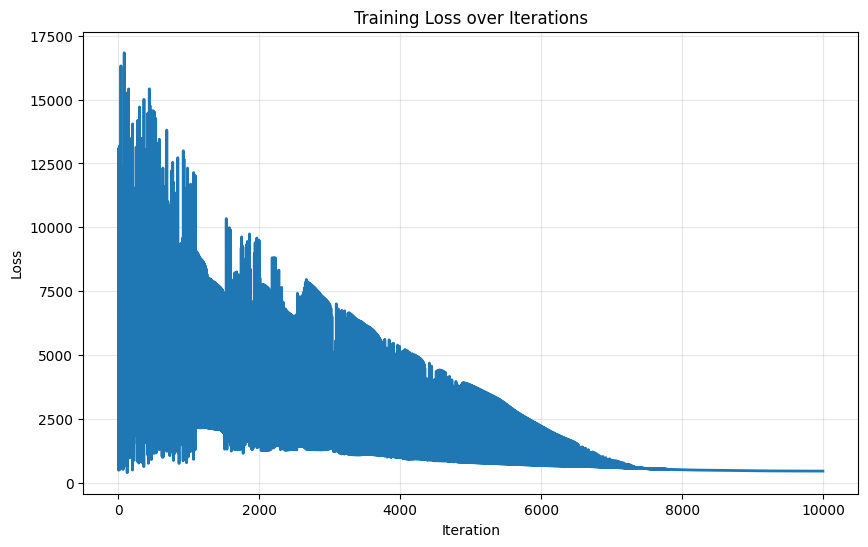

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.grid(True, alpha=0.3)

<a id="scaling"></a>

## 08 · Масштабирование: почему веса так различаются

Возраст измеряется в годах, стоимость проезда — в денежных единицах, а бинарный признак принимает только 0 и 1. Поэтому напрямую сравнивать величины их весов трудно, а градиентный спуск может работать менее устойчиво.

**Стандартизация** переводит признак к сопоставимому масштабу:

$$x'_j=\frac{x_j-\mu_j}{\sigma_j},$$

где $\mu_j$ и $\sigma_j$ оцениваются **только по обучающей выборке**. На тесте используются уже найденные значения.


In [37]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


In [38]:
from sklearn.preprocessing import StandardScaler

cols = [3, 6]

scaler = StandardScaler()
X_train_scaled = x_train.astype(float, copy=True)
X_train_scaled[:, cols] = scaler.fit_transform(x_train[:, cols])
X_test_scaled = x_test.astype(float, copy=True)
X_test_scaled[:, cols] = scaler.transform(x_test[:, cols])

In [39]:
x_train

array([[  1.    ,   1.    ,   1.    , ...,   0.    ,   0.    ,  30.5   ],
       [  1.    ,   3.    ,   1.    , ...,   0.    ,   0.    ,   7.05  ],
       [  1.    ,   2.    ,   0.    , ...,   0.    ,   2.    ,  14.5   ],
       ...,
       [  1.    ,   3.    ,   1.    , ...,   2.    ,   0.    ,  14.1083],
       [  1.    ,   1.    ,   0.    , ...,   1.    ,   2.    , 120.    ],
       [  1.    ,   1.    ,   1.    , ...,   0.    ,   1.    ,  77.2875]])

In [40]:
X_train_scaled

array([[ 1.        ,  1.        ,  1.        , ...,  0.        ,
         0.        , -0.0325683 ],
       [ 1.        ,  3.        ,  1.        , ...,  0.        ,
         0.        , -0.48733085],
       [ 1.        ,  2.        ,  0.        , ...,  0.        ,
         2.        , -0.34285405],
       ...,
       [ 1.        ,  3.        ,  1.        , ...,  2.        ,
         0.        , -0.35045024],
       [ 1.        ,  1.        ,  0.        , ...,  1.        ,
         2.        ,  1.7030926 ],
       [ 1.        ,  1.        ,  1.        , ...,  0.        ,
         1.        ,  0.8747751 ]])

### 8.1. Повторяем обучение


In [41]:
w = np.random.normal(mean, std, x_train.shape[1])

In [42]:
epoch = 10000
lr = 1e-4
last_lr = 1e-8

sch = (last_lr - lr) / (epoch - 1)
losses = []

for i in range(epoch):
  print("="*50)

  loss = log_loss(w, X_train_scaled, y_train)
  losses.append(loss)

  grad = backpropagation(w, X_train_scaled, y_train)

  w -= lr * grad

  y_pred = predict(w, X_test_scaled)
  curr_prec = precision(y_pred, y_test)
  curr_rec = recall(y_pred, y_test)
  curr_acc = accuracy(y_pred, y_test)
  curr_f1 = f1(y_pred, y_test)

  lr += sch

  print(f"Iteration: {i}; loss = {loss}; accuracy = {curr_acc}; precision = {curr_prec}; recall = {curr_rec}; f1 = {curr_f1}")


Выходные данные были обрезаны до нескольких последних строк (5000).
Iteration: 7500; loss = 301.1902991564384; accuracy = 0.8026905829596412; precision = 0.7777777777777778; recall = 0.7078651685393258; f1 = 0.7411764705882353
Iteration: 7501; loss = 301.19022993842054; accuracy = 0.8026905829596412; precision = 0.7777777777777778; recall = 0.7078651685393258; f1 = 0.7411764705882353
Iteration: 7502; loss = 301.1901607643811; accuracy = 0.8026905829596412; precision = 0.7777777777777778; recall = 0.7078651685393258; f1 = 0.7411764705882353
Iteration: 7503; loss = 301.19009163429666; accuracy = 0.8026905829596412; precision = 0.7777777777777778; recall = 0.7078651685393258; f1 = 0.7411764705882353
Iteration: 7504; loss = 301.19002254814365; accuracy = 0.8026905829596412; precision = 0.7777777777777778; recall = 0.7078651685393258; f1 = 0.7411764705882353
Iteration: 7505; loss = 301.18995350589876; accuracy = 0.8026905829596412; precision = 0.7777777777777778; recall = 0.7078651685393258

In [43]:
w

array([ 3.32970182, -0.87371481, -2.63182529, -0.43030498, -0.28962077,
       -0.15091074,  0.24879954])

Большой по модулю вес сам по себе не означает, что признак «важнее»: значение зависит от масштаба признака и его связей с другими признаками.
